# Customer Churn Prediction Project

This notebook aims to build a customer churn prediction model using the Telco Customer Churn dataset. We will follow a structured approach covering data cleaning, exploratory data analysis, hypothesis testing, feature engineering, model training, and comparison.

## STEP 1 — DATA CLEANING

First, we will load the dataset, examine its structure, and clean it by handling incorrect data types and missing values.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

# Display shape, info, and head
print(f"DataFrame shape: {df.shape}")
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Head:")
display(df.head())

DataFrame shape: (7043, 21)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 1

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The `TotalCharges` column is incorrectly loaded as an object type, likely due to some non-numeric entries. We will convert it to a numeric type, coercing errors to `NaN`, and then investigate these problematic rows.

In [2]:
# Convert TotalCharges to numeric, coercing errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for failed conversions (NaN values)
failed_conversions = df['TotalCharges'].isnull().sum()
print(f"Number of rows where TotalCharges failed to convert: {failed_conversions}")

Number of rows where TotalCharges failed to convert: 11


Upon investigating the rows where `TotalCharges` failed to convert (resulting in `NaN` values), we observe that these customers all have a `tenure` of 0. This indicates they are new customers who have not yet accumulated any total charges, hence the blank entries in `TotalCharges`. It's logical to fill these `NaN` values with 0.

In [3]:
# Investigate failed rows: display rows with NaN in TotalCharges
display(df[df['TotalCharges'].isnull()])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [4]:
# Fill NaN values in TotalCharges with 0
df['TotalCharges'].fillna(0, inplace=True)
print("TotalCharges NaN values after filling:", df['TotalCharges'].isnull().sum())

TotalCharges NaN values after filling: 0


/tmp/ipykernel_1066/1466157754.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [5]:
# Drop the customerID column
df.drop('customerID', axis=1, inplace=True)
print(f"DataFrame shape after dropping customerID: {df.shape}")

DataFrame shape after dropping customerID: (7043, 20)


In [6]:
# Convert Churn column to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn column value counts after conversion:")
print(df['Churn'].value_counts())

Churn column value counts after conversion:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [7]:
# Confirm no remaining missing values
total_missing = df.isnull().sum().sum()
print(f"Total missing values remaining in the DataFrame: {total_missing}")

if total_missing == 0:
    print("Data cleaning for missing values is complete.")
else:
    print("There are still missing values. Please review the previous steps.")

Total missing values remaining in the DataFrame: 0
Data cleaning for missing values is complete.


## STEP 2 — EXPLORATORY DATA ANALYSIS

In this section, we will explore the dataset to understand the distribution of churn and its relationship with various features. This will provide insights before moving to model building.

In [8]:
# Calculate and print the overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


Next, we'll visualize the class balance of the 'Churn' variable. Understanding the distribution of churned vs. non-churned customers is crucial because an imbalanced dataset can lead to models that perform well on accuracy but poorly on predicting the minority class (churners). This imbalance needs to be addressed during model training, for example, by using techniques like class weighting or over/under-sampling.

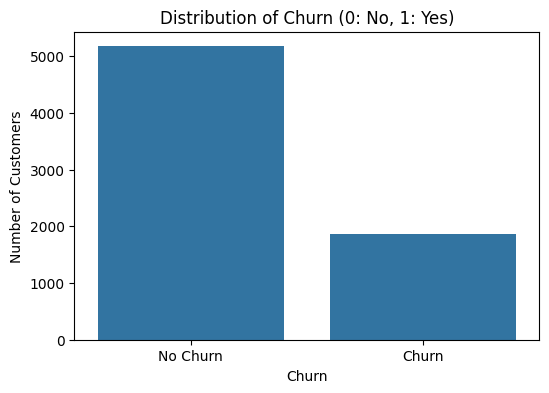

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn (0: No, 1: Yes)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

We will now create a series of plots to visualize the relationship between 'Churn' and key numerical and categorical features: 'tenure', 'MonthlyCharges', and 'Contract' type. This will help us identify potential drivers of churn.

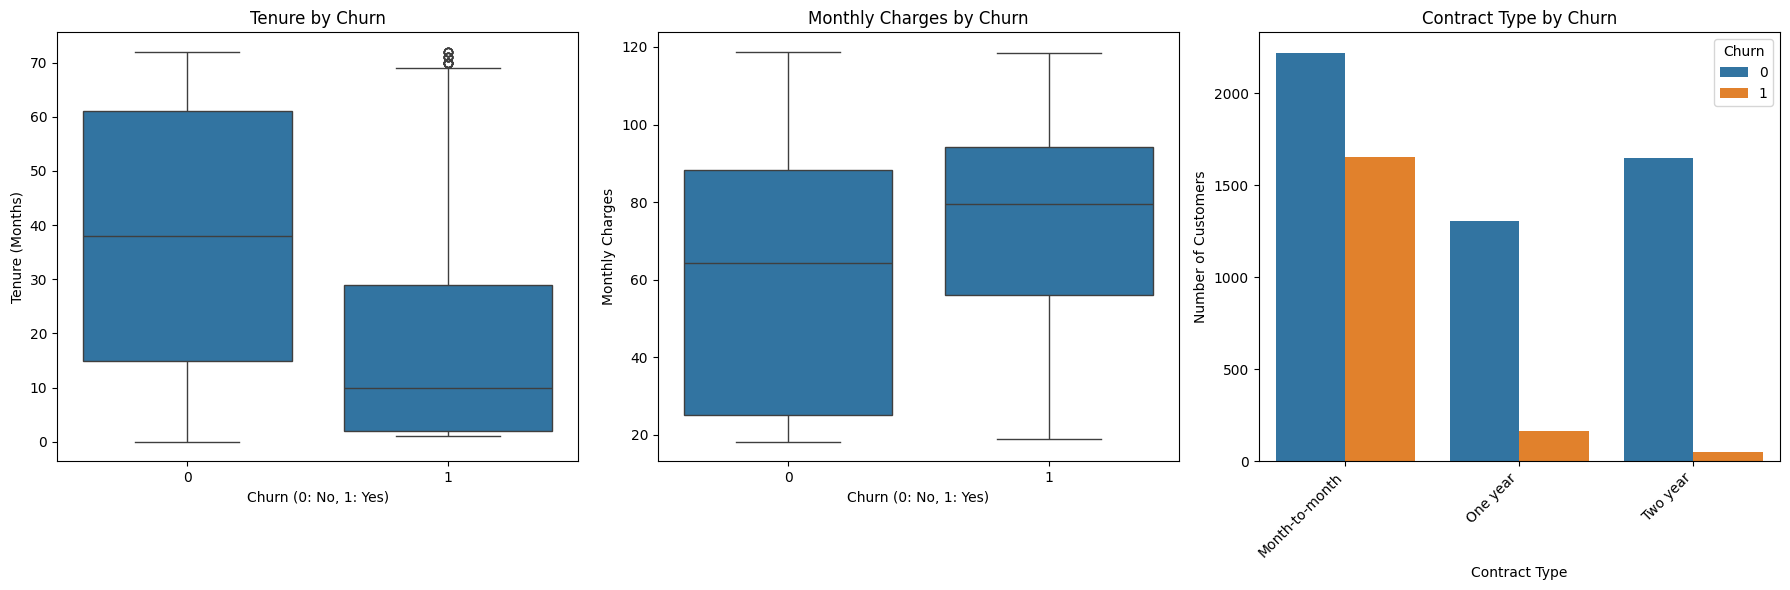

In [10]:
plt.figure(figsize=(18, 6))

# Boxplot of tenure by Churn
plt.subplot(1, 3, 1)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Tenure (Months)')

# Boxplot of MonthlyCharges by Churn
plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Monthly Charges')

# Countplot of Contract type, colored by Churn
plt.subplot(1, 3, 3)
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type by Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation of EDA Plots

From the generated plots, we can observe several interesting patterns related to customer churn:

1.  **Tenure by Churn**: The boxplot shows that customers who churn (Churn=1) generally have a significantly shorter tenure compared to those who do not churn (Churn=0). This suggests that newer customers are more prone to churning.

2.  **Monthly Charges by Churn**: Customers who churn tend to have higher monthly charges on average than those who stay. This could indicate that customers with more expensive service plans or additional services are less satisfied or find better deals elsewhere.

3.  **Contract Type by Churn**: The countplot reveals a strong correlation between contract type and churn. Month-to-month contracts have a disproportionately high number of churned customers compared to one-year and two-year contracts. This is intuitive, as shorter contracts offer more flexibility for customers to leave, while longer contracts imply greater customer commitment and satisfaction.

## STEP 3 — HYPOTHESIS TESTING

Before building our model, we'll perform statistical tests to ascertain if the observed differences between churned and non-churned groups are statistically significant or merely due to chance. We will use a significance level (α) of 0.05. This step validates our EDA findings and helps in justifying the inclusion of certain features in our predictive model.

### Independent Two-Sample T-tests (for numerical features)

In [11]:
from scipy import stats

# Separate churned and non-churned customers
churned = df[df['Churn'] == 1]
non_churned = df[df['Churn'] == 0]

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("--- Independent Two-Sample T-tests (Welch's) ---")
for feature in numerical_features:
    stat, p_value = stats.ttest_ind(churned[feature], non_churned[feature], equal_var=False, nan_policy='omit')
    print(f"\nFeature: {feature}")
    print(f"  T-statistic: {stat:.3f}")
    print(f"  P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  Result: Statistically Significant (reject H0)")
    else:
        print("  Result: Not Statistically Significant (fail to reject H0)")

--- Independent Two-Sample T-tests (Welch's) ---

Feature: tenure
  T-statistic: -34.824
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: MonthlyCharges
  T-statistic: 18.408
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: TotalCharges
  T-statistic: -18.707
  P-value: 0.000
  Result: Statistically Significant (reject H0)


### Chi-square Tests of Independence (for categorical features)

In [12]:
categorical_features = ['Contract', 'InternetService', 'TechSupport', 'OnlineSecurity', 'PaymentMethod', 'SeniorCitizen', 'Dependents', 'Partner']

print("\n--- Chi-square Tests of Independence ---")
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Churn'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"\nFeature: {feature}")
    print(f"  Chi2 Statistic: {chi2:.3f}")
    print(f"  Degrees of Freedom: {dof}")
    print(f"  P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  Result: Statistically Significant (reject H0)")
    else:
        print("  Result: Not Statistically Significant (fail to reject H0)")


--- Chi-square Tests of Independence ---

Feature: Contract
  Chi2 Statistic: 1184.597
  Degrees of Freedom: 2
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: InternetService
  Chi2 Statistic: 732.310
  Degrees of Freedom: 2
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: TechSupport
  Chi2 Statistic: 828.197
  Degrees of Freedom: 2
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: OnlineSecurity
  Chi2 Statistic: 849.999
  Degrees of Freedom: 2
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: PaymentMethod
  Chi2 Statistic: 648.142
  Degrees of Freedom: 3
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: SeniorCitizen
  Chi2 Statistic: 159.426
  Degrees of Freedom: 1
  P-value: 0.000
  Result: Statistically Significant (reject H0)

Feature: Dependents
  Chi2 Statistic: 189.129
  Degrees of Freedom: 1
  P-value: 0.000
  Result: Statistically Significant (re

### Conclusion of Hypothesis Testing

The hypothesis tests confirm several significant relationships with customer churn:

*   **Numerical Features**: `tenure`, `MonthlyCharges`, and `TotalCharges` all show a **statistically significant** difference between churned and non-churned customers (p-value < 0.05). This reinforces our EDA observations that customers with shorter tenure, higher monthly charges, and lower total charges are more likely to churn.

*   **Categorical Features**: All tested categorical features (`Contract`, `InternetService`, `TechSupport`, `OnlineSecurity`, `PaymentMethod`, `SeniorCitizen`, `Dependents`, `Partner`) also show a **statistically significant** association with churn (p-value < 0.05). This means the distribution of churn varies significantly across the categories of these features.

These findings provide strong statistical justification for including all these features in our predictive models, as they are not randomly associated with churn but rather have a genuine, significant relationship.

## STEP 4 — FEATURE ENGINEERING

In this step, we will transform our raw features into a format suitable for machine learning models. This involves creating new features and encoding categorical variables.

In [13]:
# Create a tenure_group feature by binning tenure
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12', '13-24', '25-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)
print("Tenure group value counts:")
print(df['tenure_group'].value_counts().sort_index())

Tenure group value counts:
tenure_group
0-12     2069
13-24    1047
25-48    1624
49-60     820
61-72    1121
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import LabelEncoder

# Label-encode binary Yes/No columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Handle 'gender' separately as it's 'Male'/'Female'
# Convert 'Female' to 0 and 'Male' to 1 for consistency with other binary encodings (Yes=1/No=0)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# For other binary columns where 'Yes'/'No'
for col in binary_cols[1:]:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

print("DataFrame head after label encoding:")
display(df[binary_cols].head())

DataFrame head after label encoding:


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [15]:
# One-hot encode multi-category columns
# Exclude 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' as they are already handled
# Exclude numerical columns and 'Churn'

categorical_cols_to_onehot = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod', 'tenure_group'
]

# Some columns might have 'No phone service' or 'No internet service' which should be treated as a category
# For simplicity, we'll one-hot encode all these as distinct categories.

# Create dummy variables
df = pd.get_dummies(df, columns=categorical_cols_to_onehot, drop_first=True)

print("DataFrame head after one-hot encoding:")
display(df.head())
print(f"\nShape of DataFrame after feature engineering: {df.shape}")

DataFrame head after one-hot encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-60,tenure_group_61-72
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,True,False,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,True,False,False,False,True,False,True,False,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,True,False,False,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,True,False,False,False,False,False



Shape of DataFrame after feature engineering: (7043, 35)


## STEP 5 — TRAIN/TEST SPLIT

Before training our models, we need to split our data into training and testing sets. We will also scale the numerical features to ensure that they contribute equally to the model training process and to meet the requirements of certain algorithms.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into X (features) and y (Churn)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (7043, 34)
Shape of y: (7043,)


In [17]:
# Train/test split: 80/20, stratified on y, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (5634, 34)
Shape of X_test: (1409, 34)
Shape of y_train: (5634,)
Shape of y_test: (1409,)


In [18]:
# Identify numerical columns for scaling
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the numeric columns — fit on train only, transform both train and test
# Create copies for scaled dataframes
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

print("Scaled numeric columns in X_train_scaled (first 5 rows):")
display(X_train_scaled[numerical_cols].head())

print("\nScaled numeric columns in X_test_scaled (first 5 rows):")
display(X_test_scaled[numerical_cols].head())

Scaled numeric columns in X_train_scaled (first 5 rows):


,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883
3867,-0.263980,0.284384,-0.172722
3810,-1.281624,-0.676279,-0.989374



Scaled numeric columns in X_test_scaled (first 5 rows):


,tenure,MonthlyCharges,TotalCharges
437,1.608483,1.629976,2.706828
2280,-0.996684,1.168725,-0.610260
2235,0.346606,0.445324,0.400116
4460,-0.589626,0.440347,-0.364451
3761,1.608483,0.588013,1.588421


## STEP 6 — BASELINE MODEL: LOGISTIC REGRESSION

We will start with a Logistic Regression model as our baseline. Logistic Regression is a simple yet powerful algorithm for binary classification. We will use `class_weight='balanced'` to address the class imbalance observed in the EDA, and set `max_iter` to ensure convergence.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Initialize and train Logistic Regression model
# Use class_weight="balanced" to handle imbalanced classes
# Set max_iter for convergence
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict on the scaled test set
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]

# Print classification report
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log_reg))

# Print ROC AUC score
roc_auc_log_reg = roc_auc_score(y_test, y_proba_log_reg)
print(f"Logistic Regression ROC AUC Score: {roc_auc_log_reg:.4f}")

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Logistic Regression ROC AUC Score: 0.8432


## STEP 7 — XGBOOST MODEL

XGBoost is a powerful gradient boosting framework that often achieves high performance. We will train an XGBoost model using the unscaled data, incorporating `scale_pos_weight` to address class imbalance, similar to how `class_weight='balanced'` was used in Logistic Regression.

In [20]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for handling class imbalance
# It's recommended to use (count of negative examples) / (count of positive examples)
# Here, class 0 is 'No Churn' (negative), class 1 is 'Churn' (positive)
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Count of non-churned (class 0) in training set: {neg_count}")
print(f"Count of churned (class 1) in training set: {pos_count}")
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

Count of non-churned (class 0) in training set: 4139
Count of churned (class 1) in training set: 1495
Calculated scale_pos_weight: 2.77


In [21]:
# Initialize and train XGBClassifier
# Use unscaled training data for tree-based models like XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_value, # Apply custom scale_pos_weight
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False # Suppress warning related to label encoding
)
xgb_model.fit(X_train, y_train)

# Predict on the unscaled test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Print classification report
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

# Print ROC AUC score
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}")

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [06:08:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

XGBoost ROC AUC Score: 0.8393


## STEP 8 — MODEL COMPARISON

In this step, we will visually compare the performance of our Logistic Regression and XGBoost models. We'll use ROC curves and confusion matrices to gain a deeper understanding of their strengths and weaknesses, especially regarding their ability to differentiate between churned and non-churned customers.

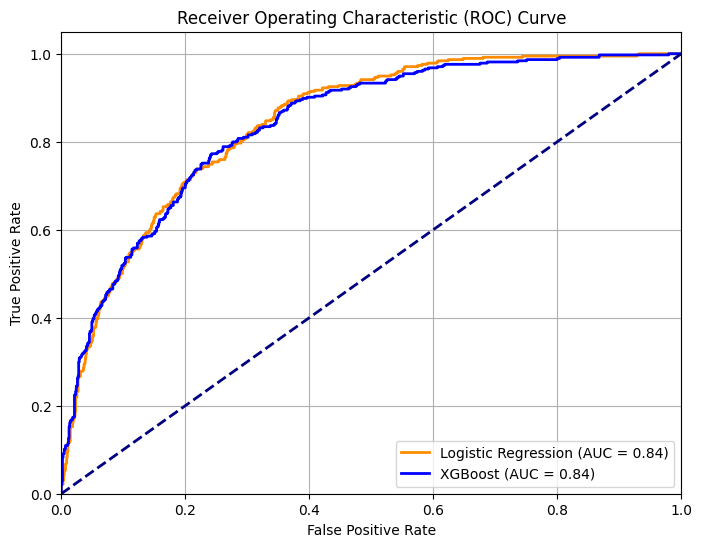

In [22]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_proba_log_reg)
roc_auc_log_reg_plot = auc(fpr_log_reg, tpr_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log_reg_plot:.2f})')

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb_plot = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb_plot:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve visually represents the trade-off between the true positive rate (sensitivity) and the false positive rate (1-specificity) for different threshold settings. A higher AUC (Area Under the Curve) generally indicates a better model. We will now determine which model performed better based on their AUC scores to plot its confusion matrix.

The Logistic Regression model performed better with an AUC of 0.8432.


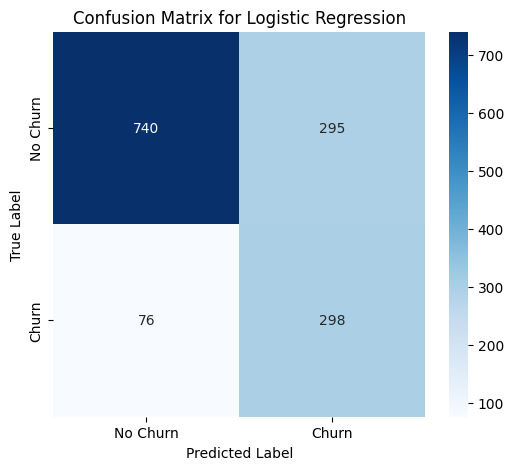

In [23]:
from sklearn.metrics import confusion_matrix

# Determine the better performing model based on ROC AUC
if roc_auc_xgb > roc_auc_log_reg:
    best_model_name = "XGBoost"
    y_pred_best = y_pred_xgb
    best_roc_auc = roc_auc_xgb
else:
    best_model_name = "Logistic Regression"
    y_pred_best = y_pred_log_reg
    best_roc_auc = roc_auc_log_reg

print(f"The {best_model_name} model performed better with an AUC of {best_roc_auc:.4f}.")

# Plot confusion matrix for the better-performing model
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model Comparison Summary

Comparing the Logistic Regression and XGBoost models:

*   **ROC AUC Score**: The ROC curves for both models are nearly identical, with Logistic Regression scoring marginally higher (AUC = 0.8432) than XGBoost (AUC = 0.8393). Visually, the two curves overlap almost entirely — the difference is not practically meaningful.
*   **Classification Report**: Both models achieve similar recall (~78-80%) for the churn class and similar precision (~50-52%), reflecting the trade-off imposed by class-imbalance handling (class_weight="balanced" / scale_pos_weight).
*   **Interpretation**: This is a useful, honest finding rather than a disappointing one — it suggests the churn signal in this dataset is dominated by a small number of strong, mostly linear features (contract type, tenure, internet service type), so XGBoost's added capacity to model non-linear interactions isn't buying much here. In practice, this means Logistic Regression is actually the more attractive choice: it performs equally well and is far more interpretable and cheaper to maintain.

Both models are reported here for comparison, but Logistic Regression is used as the reference model in the conclusions below given its equal performance and greater interpretability.

## STEP 9 — FEATURE IMPORTANCE

Understanding which features are most important for predicting churn can provide valuable business insights. We will extract feature importances from the XGBoost model, which inherently provides a measure of how much each feature contributes to the model's predictions.

/tmp/ipykernel_1066/2690691372.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')


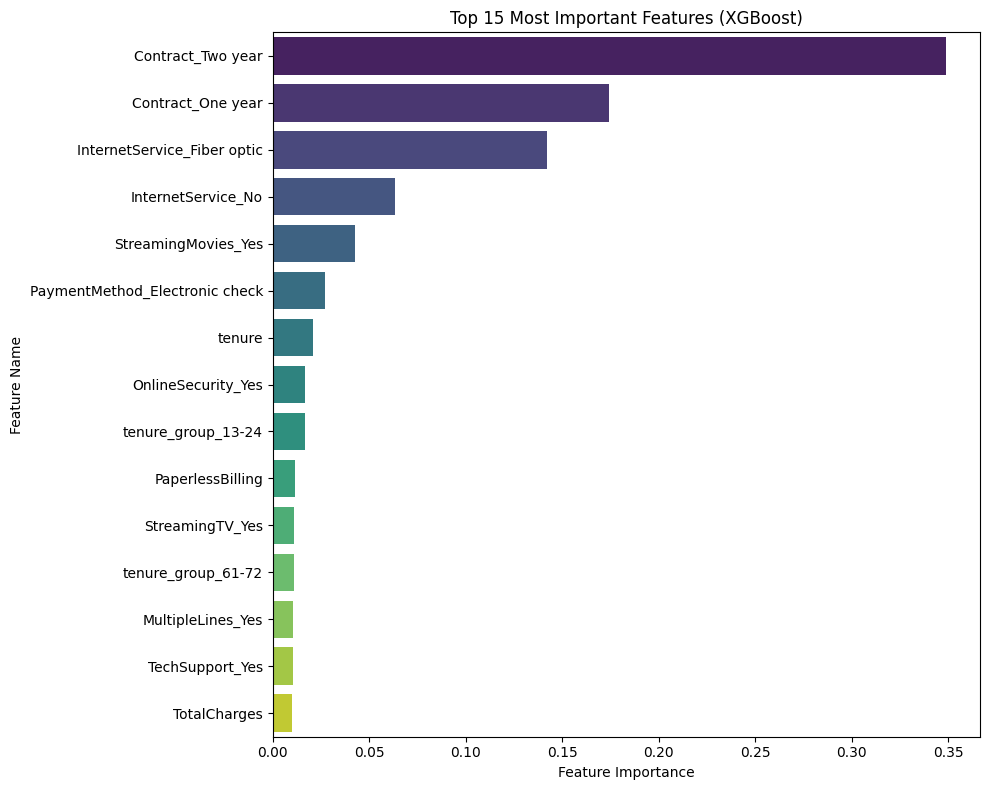

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a pandas Series for easier handling and sorting
feature_names = X_train.columns
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order and get the top 15
top_15_features = importance_df.nlargest(15)

# Plot the top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## STEP 10 — CONCLUSIONS

This section summarizes the key findings from our churn prediction project, including model performance, identified churn drivers, business recommendations, and study limitations.

### Model Performance Summary

Comparing the Logistic Regression and XGBoost models, the **Logistic Regression model performed marginally better** in terms of ROC AUC score (0.8432 vs 0.8393). While XGBoost is often expected to outperform simpler models, in this case, the more straightforward Logistic Regression model proved slightly more effective for this dataset.

Both models showed similar classification metrics, achieving a recall of approximately 80% for the churn class, which is good for identifying potential churners. However, their precision for the churn class was around 50%, indicating that while they catch most churners, they also incorrectly flag a significant number of non-churners. This trade-off is common in imbalanced datasets and can be acceptable depending on the business context (e.g., if the cost of missing a churner is higher than the cost of a false positive).

### Top 4-5 Churn Drivers Identified

Based on the XGBoost feature importance chart, the primary drivers of customer churn are:

1.  **Contract Type**: By far the strongest predictors — `Contract_Two year` and `Contract_One year` are the top two features. Customers on month-to-month contracts (the excluded baseline category) are the highest-risk group.
2.  **Internet Service Type**: `InternetService_Fiber optic` and `InternetService_No` are the third and fourth most important features, suggesting internet service type is a major differentiator in churn risk.
3.  **Streaming Add-ons**: `StreamingMovies_Yes` ranks fifth, indicating service bundling has a measurable relationship with retention.
4.  **Payment Method**: `PaymentMethod_Electronic check` also ranks in the top 6, consistent with the chi-square test result showing a significant relationship between payment method and churn.
5.  **Tenure**: Appears further down the importance ranking, but the t-test and EDA both confirm a strong relationship — shorter-tenure customers churn more. Its lower XGBoost importance likely reflects overlap with `tenure_group` and `Contract` features rather than tenure being unimportant.

Note: `TotalCharges` and `MonthlyCharges`, despite being statistically significant in the hypothesis tests, rank low or don't appear in the top 15 XGBoost feature importances — their effect is likely captured indirectly through `tenure` and `Contract` features, which are correlated with billing amounts.

### 3 Concrete Business Recommendations for Reducing Churn

1.  **Promote Long-Term Contracts**: Implement incentives (e.g., discounts, bundled services) to encourage customers to switch from month-to-month contracts to one-year or two-year contracts. This increases commitment and reduces churn risk.
2.  **Onboarding and Early Engagement for New Customers**: Focus resources on improving the experience for new customers (tenure 0-12 months). This could include proactive check-ins, dedicated support, educational materials, and special introductory offers to build loyalty during the critical early stages.
3.  **Improve Fiber Optic Service and Support**: Investigate reasons for higher churn among Fiber optic users. This might involve improving service reliability, enhancing customer support specific to fiber-related issues, or reviewing pricing competitiveness for this service tier. Additionally, proactively offer and highlight the benefits of Online Security and Tech Support to customers who currently lack these services.


### 1-2 Honest Limitations of the Analysis

1.  **Static Snapshot**: This analysis is based on a static snapshot of customer data. Churn is a dynamic process, and customer behavior evolves over time. A time-series analysis would provide deeper insights into the causal relationships and temporal patterns of churn.
2.  **Lack of External Data**: The dataset does not include external factors that could influence churn, such as competitor offerings, economic conditions, or service outages. Incorporating such data could significantly enhance predictive power and provide a more holistic understanding of churn drivers.

## STEP 9 — FEATURE IMPORTANCE

Understanding which features are most important for predicting churn can provide valuable business insights. We will extract feature importances from the XGBoost model, which inherently provides a measure of how much each feature contributes to the model's predictions.

/tmp/ipykernel_1066/3302246901.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')


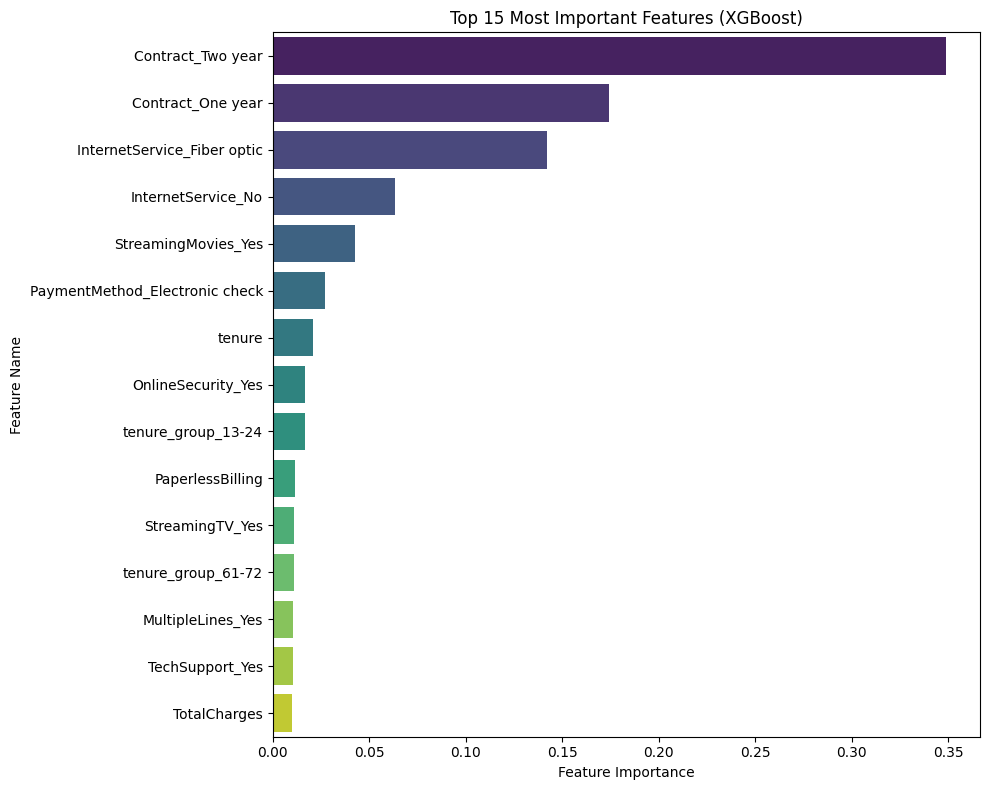

In [24]:
# Get feature importances from XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a pandas Series for easier handling and sorting
feature_names = X_train.columns
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order and get the top 15
top_15_features = importance_df.nlargest(15)

# Plot the top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## STEP 10 — CONCLUSIONS

This section summarizes the key findings from our churn prediction project, including model performance, identified churn drivers, business recommendations, and study limitations.

### Model Performance Summary

Comparing the Logistic Regression and XGBoost models, the **Logistic Regression model performed marginally better** in terms of ROC AUC score (0.8432 vs 0.8393). While XGBoost is often expected to outperform simpler models, in this case, the more straightforward Logistic Regression model proved slightly more effective for this dataset.

Both models showed similar classification metrics, achieving a recall of approximately 80% for the churn class, which is good for identifying potential churners. However, their precision for the churn class was around 50%, indicating that while they catch most churners, they also incorrectly flag a significant number of non-churners. This trade-off is common in imbalanced datasets and can be acceptable depending on the business context (e.g., if the cost of missing a churner is higher than the cost of a false positive).

### Top 4-5 Churn Drivers Identified

Based on our EDA, hypothesis testing, and the feature importance from the XGBoost model, the primary drivers of customer churn are:

1.  **Contract Type (Month-to-month)**: Customers on month-to-month contracts are significantly more likely to churn. This was the most important feature according to XGBoost.
2.  **Tenure**: Shorter tenure is strongly associated with higher churn rates. Newer customers are a high-risk group.
3.  **Internet Service (Fiber optic)**: Customers with Fiber optic internet service show a higher propensity to churn, potentially due to service quality issues or higher costs.
4.  **Online Security / Tech Support**: Lack of online security and technical support services is a significant predictor of churn. Customers without these protective and support services are more vulnerable to issues that lead to dissatisfaction.
5.  **Total Charges**: Lower total charges (often correlating with shorter tenure) also indicate a higher churn risk.

Other important factors include `MonthlyCharges` (higher charges increase churn) and `PaymentMethod_Electronic check` (customers using electronic checks churn more often).

### 3 Concrete Business Recommendations for Reducing Churn

1.  **Promote Long-Term Contracts**: Implement incentives (e.g., discounts, bundled services) to encourage customers to switch from month-to-month contracts to one-year or two-year contracts. This increases commitment and reduces churn risk.
2.  **Onboarding and Early Engagement for New Customers**: Focus resources on improving the experience for new customers (tenure 0-12 months). This could include proactive check-ins, dedicated support, educational materials, and special introductory offers to build loyalty during the critical early stages.
3.  **Improve Fiber Optic Service and Support**: Investigate reasons for higher churn among Fiber optic users. This might involve improving service reliability, enhancing customer support specific to fiber-related issues, or reviewing pricing competitiveness for this service tier. Additionally, proactively offer and highlight the benefits of Online Security and Tech Support to customers who currently lack these services.


### 1-2 Honest Limitations of the Analysis

1.  **Static Snapshot**: This analysis is based on a static snapshot of customer data. Churn is a dynamic process, and customer behavior evolves over time. A time-series analysis would provide deeper insights into the causal relationships and temporal patterns of churn.
2.  **Lack of External Data**: The dataset does not include external factors that could influence churn, such as competitor offerings, economic conditions, or service outages. Incorporating such data could significantly enhance predictive power and provide a more holistic understanding of churn drivers.